# 🔧 Vibration Analysis — Machine Monitoring

**Goal:** Read vibration data from Excel, clean it, analyze patterns in time and frequency domains, and determine if the machine is healthy.

---

## The Full Pipeline:

```
RAW DATA
    ↓
1. LOAD & CLEAN         → remove 999, NaN, convert types
    ↓
2. TIME DOMAIN          → RMS, Peak, Crest Factor, Kurtosis
    ↓
3. FREQUENCY DOMAIN     → FFT → 'which frequencies are present?'
    ↓
4. DIAGNOSE             → combine steps 2+3 → 'is the machine OK?'
    ↓
5. VISUALIZE            → plot all of it in a dashboard
```

---
## STEP 1 — Import Libraries

We need these libraries:
- **pandas** → reading Excel, working with tables
- **numpy** → math (FFT, RMS, statistics)
- **matplotlib** → all charts
- **scipy** → advanced signal processing (Welch PSD, find_peaks)

📚 *Google search to learn more:* `"pandas read_excel tutorial"`, `"numpy fft python"`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
from scipy.fft import fft, fftfreq

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


---
## STEP 2 — Load & Inspect Raw Data

First we always just **look** at the data before doing anything.

**What to check:**
- What columns do we have?
- How many rows?
- What do the first/last rows look like?
- Are there any obvious problems?

📚 *Google search:* `"pandas dataframe describe"`, `"pandas isnull sum"`

In [2]:
FILE_PATH = 'vibration_data.xlsx'

# Read the Excel file
df = pd.read_excel(FILE_PATH)

print('=== FIRST LOOK AT THE DATA ===')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('First 5 rows:')
df.head()

=== FIRST LOOK AT THE DATA ===
Shape: 9950 rows × 2 columns

First 5 rows:


,timestamp_s,accel_g
0,0.000,-0.002878
1,0.001,0.028538
2,0.002,0.00671
3,0.003,0.015887
4,0.004,-0.027731


In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== NULL VALUES ===')
print(df.isnull().sum())

=== DATA TYPES ===
timestamp_s    float64
accel_g         object
dtype: object

=== NULL VALUES ===
timestamp_s     0
accel_g        20
dtype: int64


In [4]:
print('=== STATISTICS (raw, before cleaning) ===')
# Note: describe() only works on numeric columns!
# accel_g is still 'object' type here - that's why we need to convert it
df.describe(include='all')

=== STATISTICS (raw, before cleaning) ===


,timestamp_s,accel_g
count,9950.000000,9930
unique,NaN,9922
top,NaN,SENSOR_ERROR
freq,NaN,5
mean,4.998973,NaN
std,2.888422,NaN
min,0.000000,NaN
25%,2.496500,NaN
50%,4.996000,NaN
75%,7.501500,NaN


---
## STEP 3 — Data Cleaning

We found problems in Step 2:
1. `accel_g` column is `object` type (string) — some cells contain text like `'SENSOR_ERROR'`
2. After converting to numbers, those strings become `NaN` (Not a Number)
3. Some values are `999` — physically impossible, these are sensor error codes

**How do you know 999 is an error in real life?**
- Look at `df.describe()` → max is 999 but everything else is near 0 → suspicious!
- Physically: a car cannot vibrate at 999g (it would be destroyed)
- Read the sensor documentation — 999 is a common sentinel value for disconnection/fault

📚 *Google search:* `"pandas to_numeric errors coerce"`, `"pandas dropna subset"`

In [5]:
# Convert columns to numeric
# errors='coerce' means: if a value can't be converted to a number, make it NaN
df['timestamp_s'] = pd.to_numeric(df['timestamp_s'], errors='coerce')
df['accel_g'] = pd.to_numeric(df['accel_g'], errors='coerce')

print('=== DATA TYPES AFTER CONVERSION ===')
print(df.dtypes)
print()
print('=== NULL VALUES AFTER CONVERSION ===')
# The 'SENSOR_ERROR' text rows became NaN
print(df.isnull().sum())

=== DATA TYPES AFTER CONVERSION ===
timestamp_s    float64
accel_g        float64
dtype: object

=== NULL VALUES AFTER CONVERSION ===
timestamp_s     0
accel_g        25
dtype: int64


In [6]:
# Drop NaN rows
df = df.dropna(subset=['timestamp_s', 'accel_g'])

print('=== AFTER DROPPING NaN ROWS ===')
print(f'Remaining rows: {len(df)}')
print()
print('Statistics now (notice max = 999 → still has sensor error spikes!):')
df.describe()

=== AFTER DROPPING NaN ROWS ===
Remaining rows: 9925

Statistics now (notice max = 999 → still has sensor error spikes!):


,timestamp_s,accel_g
count,9925.000000,9925.000000
mean,4.998371,0.503445
std,2.889620,22.418064
min,0.000000,-0.124211
25%,2.494249,-0.021474
50%,4.993499,0.000235
75%,7.503750,0.021867
max,10.000000,999.000000


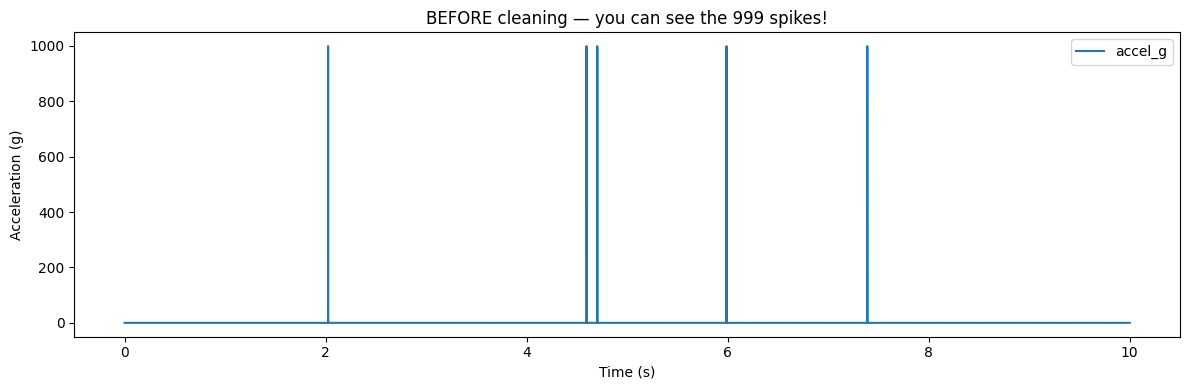

In [7]:
# PLOT BEFORE removing 999 — so you can SEE why we need to remove them
df.plot(x='timestamp_s', y='accel_g', figsize=(12, 4),
        title='BEFORE cleaning — you can see the 999 spikes!',
        xlabel='Time (s)', ylabel='Acceleration (g)')
plt.tight_layout()
plt.show()

In [8]:
# Find the 999 values — confirm they are sensor errors
sensor_errors = df[df['accel_g'] == 999]
print(f'Found {len(sensor_errors)} sensor error rows:')
sensor_errors

Found 5 sensor error rows:


,timestamp_s,accel_g
2016,2.024202,999.0
4576,4.595460,999.0
4683,4.702470,999.0
5958,5.987599,999.0
7349,7.388739,999.0


In [9]:
# Remove rows with 999 (sensor error code)
# Boolean operation: keep only rows where accel_g is NOT equal to 999
df = df[df['accel_g'] != 999]

print('=== AFTER REMOVING 999 ERROR ROWS ===')
print(f'Clean rows: {len(df)}')
print()
df.describe()

=== AFTER REMOVING 999 ERROR ROWS ===
Clean rows: 9920



,timestamp_s,accel_g
count,9920.000000,9920.000000
mean,4.998401,0.000170
std,2.890073,0.033849
min,0.000000,-0.124211
25%,2.493999,-0.021488
50%,4.993999,0.000215
75%,7.505001,0.021846
max,10.000000,0.125317


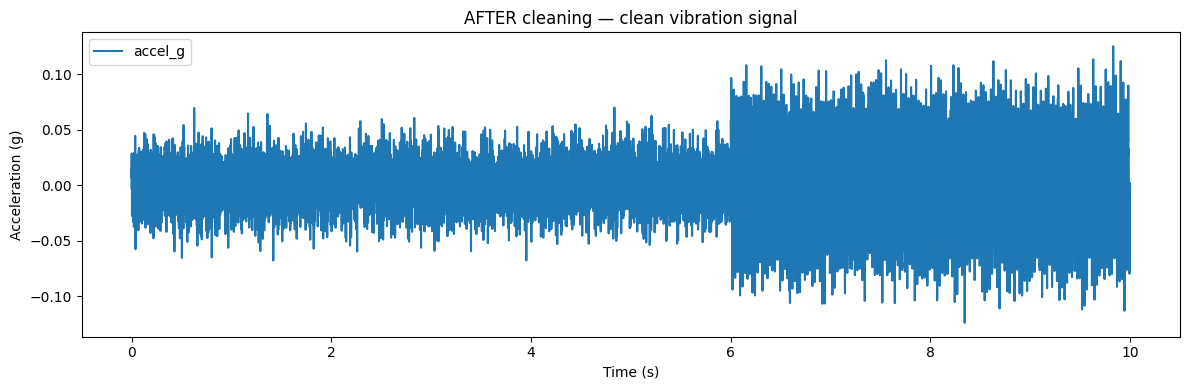

Data is clean and ready for analysis ✓


In [10]:
# PLOT AFTER cleaning — much better!
df.plot(x='timestamp_s', y='accel_g', figsize=(12, 4),
        title='AFTER cleaning — clean vibration signal',
        xlabel='Time (s)', ylabel='Acceleration (g)')
plt.tight_layout()
plt.show()

print('Data is clean and ready for analysis ✓')

---
## STEP 4 — Sampling Rate

Before doing FFT we need to know the **sampling rate (fs)** — how many measurements per second.

**Why?**
- FFT needs to know the time between samples to calculate correct frequencies
- `fs = 1 / Δt` where `Δt` is the time between samples

📚 *Google search:* `"sampling frequency signal processing"`, `"nyquist theorem"`

In [ ]:
# Calculate sampling rate
# diff() calculates the difference between consecutive values
# median() is more robust than mean() in case of occasional irregular gaps
dt = df['timestamp_s'].diff().median()   # average time step in seconds
fs = 1.0 / dt                            # samples per second (Hz), fs is the sampling frequency.

print(f'Time step (dt): {dt:.6f} seconds')
print(f'Sampling rate (fs): {fs:.1f} Hz')
print(f'Total duration: {df["timestamp_s"].max():.2f} seconds')
print(f'Total samples: {len(df):,}')

Time step (dt): 0.001000 seconds
Sampling rate (fs): 999.9 Hz
Total duration: 10.00 seconds
Total samples: 9,920


---
## STEP 5 — Time Domain Analysis

Before looking at frequencies, we calculate statistics directly from the signal.
These metrics tell us about the **overall health** of the machine.

### Metrics explained:

| Metric | Formula | Meaning |
|--------|---------|--------|
| **RMS** | `√(mean(x²))` | Overall vibration energy. High = more vibration = potential problem |
| **Peak** | `max(|x|)` | Largest single spike |
| **Crest Factor** | `Peak / RMS` | Measures 'spikiness'. >5 → bearing damage |
| **Kurtosis** | statistical | Distribution shape. >4 → non-Gaussian → early bearing fault |

📚 *Google search/YouTube:* `"vibration analysis RMS crest factor"`, `"kurtosis bearing fault detection"`

https://www.youtube.com/watch?v=yxYxkDWEDWQ

📖 *Reference standard:* ISO 10816 — defines what RMS values are acceptable for different machine classes

In [12]:
# Get the acceleration values as a numpy array for math
a = df['accel_g'].values

# ── RMS (Root Mean Square) ─────────────────────────────
# Formula: sqrt( mean(x²) )
# This is the most basic health indicator — measures overall vibration energy
rms = np.sqrt(np.mean(a**2))

# ── Peak ──────────────────────────────────────────────
# Maximum absolute value (the biggest spike, positive or negative)
peak = np.max(np.abs(a))

# ── Crest Factor ──────────────────────────────────────
# Ratio of Peak to RMS
# Normal smooth vibration: ~1.4–2.5
# Impulsive events (bearing damage): >5
crest_factor = peak / rms

# ── Kurtosis ──────────────────────────────────────────
# Measures the 'tailedness' of the distribution
# Normal random signal → Kurtosis ≈ 3
# Kurtosis > 4 → unusual spikes → potential bearing fault
# pandas kurtosis() returns 'excess kurtosis' (already minus 3), so we add 3 back
kurtosis = pd.Series(a).kurtosis() + 3

# ── Peak-to-Peak ──────────────────────────────────────
peak_to_peak = np.max(a) - np.min(a)

print('=== TIME DOMAIN STATISTICS ===')
print(f'RMS:            {rms:.5f} g')
print(f'Peak:           {peak:.5f} g')
print(f'Peak-to-Peak:   {peak_to_peak:.5f} g')
print(f'Crest Factor:   {crest_factor:.2f}  (normal: <3, warning: 3-5, fault: >5)')
print(f'Kurtosis:       {kurtosis:.2f}  (normal: ~3, warning: >4, fault: >6)')

=== TIME DOMAIN STATISTICS ===
RMS:            0.03385 g
Peak:           0.12532 g
Peak-to-Peak:   0.24953 g
Crest Factor:   3.70  (normal: <3, warning: 3-5, fault: >5)
Kurtosis:       3.30  (normal: ~3, warning: >4, fault: >6)


---
## STEP 6 — Frequency Domain Analysis (FFT)

This is the **core** of vibration analysis. FFT converts the time signal into a frequency spectrum.

### How FFT works:

Any repeating vibration pattern can be decomposed into a sum of sine waves at different frequencies.
FFT tells us **which frequencies are present** and **how strong** (amplitude) they are.

**The math formula:**
```
X[k] = Σ x[n] · e^(-j·2π·k·n/N)    for k = 0, 1, …, N/2

where:
  x[n]  = our acceleration signal
  X[k]  = complex number at frequency bin k
  |X[k]|= amplitude at that frequency
  N     = total number of samples
  fs    = sampling frequency
```

**What peaks in the FFT mean for a machine:**

| Frequency pattern | Likely cause |
|---|---|
| 1× rotation speed | Imbalance |
| 2× rotation speed | Misalignment |
| High freq (>1000 Hz) | Bearing defects |
| Broad noise floor | Looseness |

📚 *Google search:* `"FFT vibration analysis tutorial"`, `"scipy.fft python example"`

📖 *Reference article used:* https://www.geeksforgeeks.org/artificial-intelligence/spectrum-analysis-in-python/

In [ ]:
N = len(a)

# ── Step 1: Apply FFT ──────────────────────────────────
# fft() returns complex numbers for each frequency bin
# https://docs.scipy.org/doc/scipy/reference/fft.html
fft_vals = fft(a)

# ── Step 2: Create frequency axis ─────────────────────
# fftfreq() gives us what frequency each bin corresponds to
# d=1/fs means: 'each sample is 1/fs seconds apart'
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fftfreq.html#scipy.fft.fftfreq
freqs = fftfreq(N, d=1/fs)

# ── Step 3: Keep only positive frequencies ─────────────
# Our signal is real (not complex), so the spectrum is symmetric
# We only need the positive half (0 Hz to fs/2 Hz)
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]

# ── Step 4: Calculate amplitude ────────────────────────
# np.abs() extracts the magnitude from the complex number
# Multiply by 2/N to convert from two-sided to one-sided spectrum
amps = (2 / N) * np.abs(fft_vals[pos_mask])

print(f'FFT computed. Frequency resolution: {freqs_pos[1] - freqs_pos[0]:.3f} Hz')
print(f'Max frequency visible: {freqs_pos.max():.1f} Hz (= fs/2 = Nyquist frequency)')

FFT computed. Frequency resolution: 0.101 Hz
Max frequency visible: 499.8 Hz (= fs/2 = Nyquist frequency)


In [ ]:
# ── Find dominant frequency peaks ─────────────────────
# find_peaks() finds local maxima in the spectrum
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
# prominence: ignore peaks smaller than 5% of the maximum
# distance: peaks must be at least 5 bins apart
peak_idx, _ = find_peaks(amps,
                          prominence=np.max(amps) * 0.05,
                          distance=5)

# Sort by amplitude (strongest first), zip means we pair each frequency with its amplitude, 
# then sort by amplitude and take top 5
dominant = sorted(zip(freqs_pos[peak_idx], amps[peak_idx]),
                  key=lambda x: -x[1])[:5]

print('=== TOP DOMINANT FREQUENCIES ===')
for i, (freq, amp) in enumerate(dominant, 1):
    print(f'  {i}. {freq:7.2f} Hz  →  Amplitude: {amp:.5f} g')

=== TOP DOMINANT FREQUENCIES ===
  1.   40.32 Hz  →  Amplitude: 0.02273 g
  2.  201.09 Hz  →  Amplitude: 0.00884 g
  3.   39.61 Hz  →  Amplitude: 0.00462 g
  4.   41.43 Hz  →  Amplitude: 0.00366 g
  5.  201.59 Hz  →  Amplitude: 0.00359 g


### Welch PSD (Power Spectral Density)

Welch is a **smoother version** of FFT. It:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

- Divides the signal into overlapping windows
- Calculates FFT for each window
- **Averages** all the results → less noise, more stable

**Units:** g²/Hz (energy per unit frequency)

Use Welch when your signal is noisy and you want a cleaner picture of what frequencies dominate.

📚 *Google search:* `"scipy welch PSD python"`, `"power spectral density vibration"`

In [ ]:
# Welch PSD
#
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
#
# nperseg = size of each window (1024 points, or N//4 if signal is short)
# scaling='density' gives us g²/Hz units
f_welch, psd = welch(a, fs=fs,
                     nperseg=min(1024, N//4),
                     scaling='density')

print(f'Welch PSD computed.')
print(f'Frequency resolution: {f_welch[1] - f_welch[0]:.3f} Hz')
print(f'Number of frequency bins: {len(f_welch)}')

Welch PSD computed.
Frequency resolution: 0.976 Hz
Number of frequency bins: 513


---
## STEP 7 — Machine Health Diagnosis

Now we combine the time-domain metrics and frequency peaks to give a **verdict**.

Time-domain metrics and frequency peaks are combined to give a diagnostic verdict on machine health by using time-domain data to identify that a fault exists and frequency-domain analysis (FFT) to determine what the fault is. This approach, often called vibration signature analysis, compares current operational data against a baseline to detect deviations. 

https://dsp.stackexchange.com/questions/9724/peak-to-peak-amplitude-of-sum-of-sinusoidals-harmonic-frequencies/9740#9740

**The thinking path that leads to these rules:**
1. RMS → basic energy check
2. Crest Factor → catches spikes that RMS misses
3. Kurtosis → early warning of bearing damage (even before Crest Factor rises)
4. Dominant frequency → identifies WHAT is vibrating

📚 *Google search:* 

`"ISO 10816 vibration standard"`
    https://www.spminstrument.com/measuring-techniques/vibration-monitoring/vibration-measurement-and-analysis/

`"bearing fault diagnosis vibration"`
    https://medium.com/@RashmiW/vibration-analysis-of-bearings-for-early-fault-detection-a-matlab-case-study-1e2ff244c78e


In [16]:
# ── THRESHOLDS — tune these for your specific machine ──
# These come from ISO 10816 / manufacturer specs
RMS_WARNING_G      = 0.10    # RMS > 0.10 g  → warning
RMS_CRITICAL_G     = 0.20    # RMS > 0.20 g  → critical
CREST_WARNING      = 3.0     # Crest Factor > 3 → monitor
CREST_CRITICAL     = 5.0     # Crest Factor > 5 → bearing damage
KURTOSIS_WARNING   = 4.0     # Kurtosis > 4 → non-Gaussian
KURTOSIS_CRITICAL  = 6.0     # Kurtosis > 6 → bearing fault
DOMINANT_FREQ_WARN = 50.0    # Dominant freq > 50 Hz → inspect bearings

print('Thresholds configured ✓')

Thresholds configured ✓


In [17]:
issues   = []
warnings = []

# ── RMS check ─────────────────────────────────────────────────────────────────
if rms > RMS_CRITICAL_G:
    issues.append(f'CRITICAL: RMS = {rms:.4f} g  (threshold {RMS_CRITICAL_G} g)')
elif rms > RMS_WARNING_G:
    warnings.append(f'WARNING: RMS = {rms:.4f} g  (threshold {RMS_WARNING_G} g)')
else:
    print(f'✓ RMS = {rms:.4f} g  (normal, below {RMS_WARNING_G} g)')

# ── Crest Factor check ────────────────────────────────────────────────────────
# Peak / RMS ratio. High ratio = impulsive events = bearing damage
if crest_factor > CREST_CRITICAL:
    issues.append(f'HIGH Crest Factor = {crest_factor:.2f} → possible bearing damage')
elif crest_factor > CREST_WARNING:
    warnings.append(f'Elevated Crest Factor = {crest_factor:.2f} → monitor closely')
else:
    print(f'✓ Crest Factor = {crest_factor:.2f}  (normal, below {CREST_WARNING})')

# ── Kurtosis check ────────────────────────────────────────────────────────────
# Kurtosis measures 'tailedness' of distribution
# Normal Gaussian signal = 3.0
# Higher = more non-Gaussian = more micro-impacts = early bearing fault
if kurtosis > KURTOSIS_CRITICAL:
    issues.append(f'HIGH Kurtosis = {kurtosis:.2f} → early bearing fault signature')
elif kurtosis > KURTOSIS_WARNING:
    warnings.append(f'Elevated Kurtosis = {kurtosis:.2f} → non-Gaussian vibration')
else:
    print(f'✓ Kurtosis = {kurtosis:.2f}  (normal, ~3.0)')

# ── Dominant frequency check ──────────────────────────────────────────────────
if dominant:
    dom_f, dom_a = dominant[0]
    if dom_f > DOMINANT_FREQ_WARN:
        warnings.append(f'Dominant freq = {dom_f:.1f} Hz → inspect rotating components')
    else:
        print(f'✓ Dominant frequency = {dom_f:.1f} Hz (within normal range)')

# ── Overall verdict ───────────────────────────────────────────────────────────
print()
print('=== MACHINE HEALTH VERDICT ===')
if issues:
    print('🔴  FAULT DETECTED')
    for issue in issues:
        print(f'  [FAULT] {issue}')
elif warnings:
    print('🟡  MONITOR CLOSELY')
    for warn in warnings:
        print(f'  [WARN]  {warn}')
else:
    print('🟢  MACHINE OK — all parameters within normal limits')

✓ RMS = 0.0338 g  (normal, below 0.1 g)
✓ Kurtosis = 3.30  (normal, ~3.0)
✓ Dominant frequency = 40.3 Hz (within normal range)

=== MACHINE HEALTH VERDICT ===
🟡  MONITOR CLOSELY
  [WARN]  Elevated Crest Factor = 3.70 → monitor closely


---
## STEP 8 — Visualization Dashboard

Now we plot everything together in a 4-panel dashboard:

1. **Time signal** — raw waveform with RMS and Peak lines
2. **FFT spectrum** — amplitude vs frequency
3. **Welch PSD** — smoothed power spectrum
4. **KPI summary** — all the numbers in one place

📚 *Google search:* `"matplotlib gridspec subplots"`, `"matplotlib semilogy"`

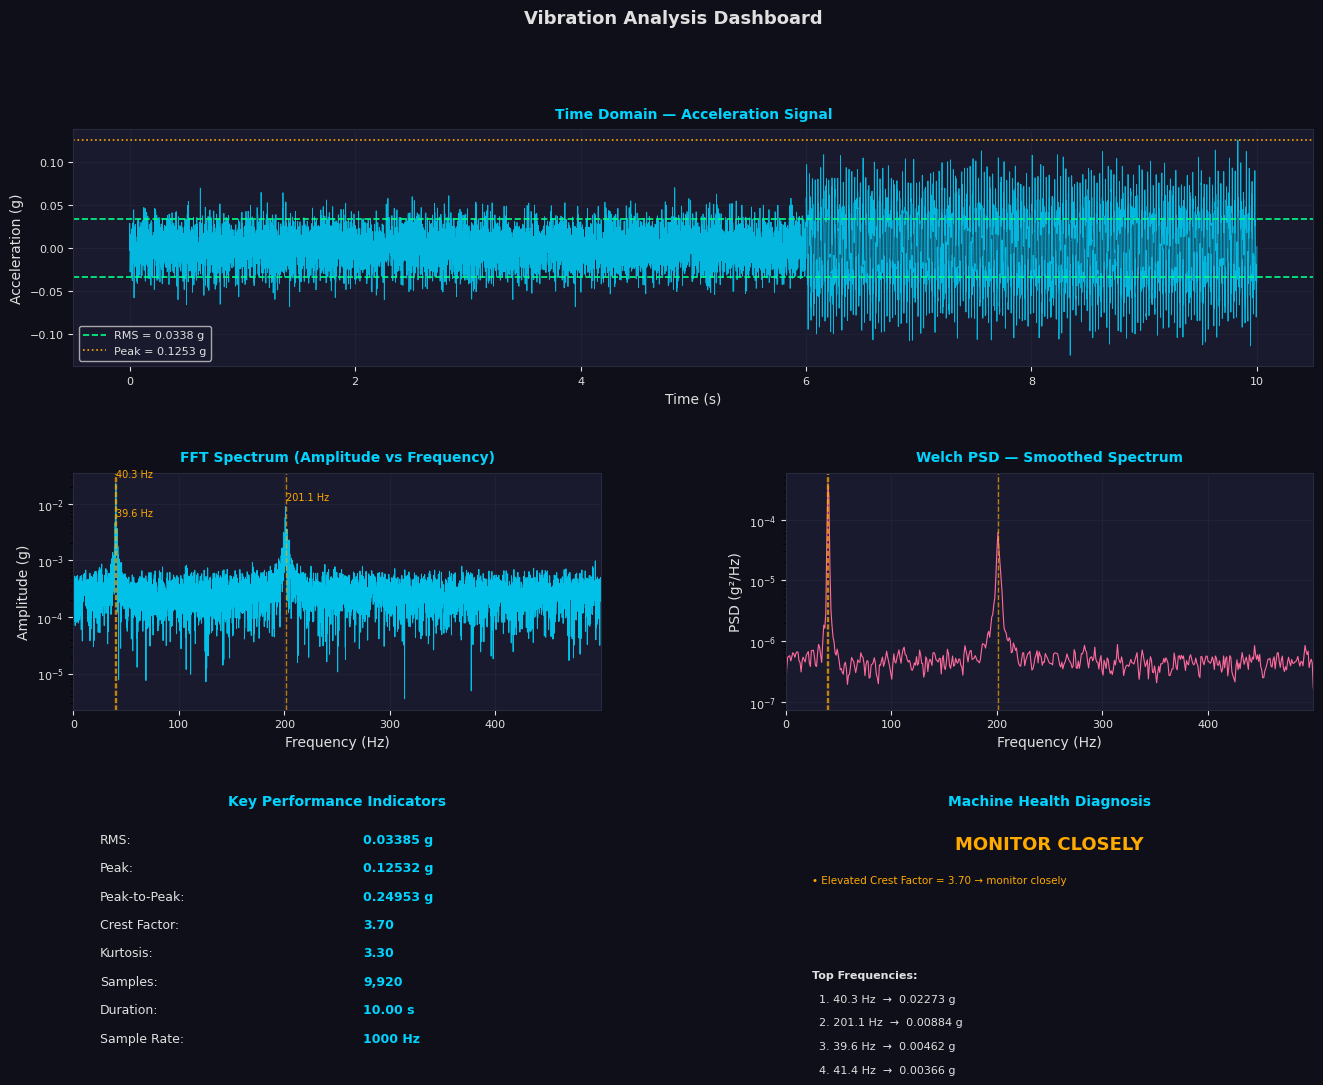

Dashboard saved as vibration_dashboard.png ✓


In [18]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12), facecolor='#0f0f1a')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Color scheme
DARK_BG  = '#0f0f1a'
PANEL_BG = '#1a1a2e'
ACCENT   = '#00d4ff'
WARN     = '#ffaa00'
GOOD     = '#00ff88'
TEXT     = '#e0e0e0'
GRID     = '#2a2a3e'

def style_ax(ax, title):
    ax.set_facecolor(PANEL_BG)
    ax.spines[:].set_color(GRID)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, color=ACCENT, fontsize=10, fontweight='bold', pad=8)
    ax.grid(True, color=GRID, alpha=0.7, linewidth=0.5)

# ── Panel 1: Time-domain waveform (spans full width) ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['timestamp_s'], df['accel_g'], color=ACCENT, lw=0.6, alpha=0.85)
ax1.axhline(rms,  color=GOOD, lw=1.2, ls='--', label=f'RMS = {rms:.4f} g')
ax1.axhline(-rms, color=GOOD, lw=1.2, ls='--')
ax1.axhline(peak, color=WARN, lw=1.2, ls=':', label=f'Peak = {peak:.4f} g')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (g)')
ax1.legend(facecolor=PANEL_BG, labelcolor=TEXT, fontsize=8)
style_ax(ax1, 'Time Domain — Acceleration Signal')

# ── Panel 2: FFT Spectrum ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(freqs_pos, amps, color=ACCENT, lw=0.7, alpha=0.9)
for i, (f, amp) in enumerate(dominant[:3]):
    ax2.axvline(f, color=WARN, lw=1, ls='--', alpha=0.7)
    ax2.text(f + 0.5, amp * 1.3, f'{f:.1f} Hz', color=WARN, fontsize=7)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude (g)')
ax2.set_xlim(0, fs / 2)
style_ax(ax2, 'FFT Spectrum (Amplitude vs Frequency)')

# ── Panel 3: Welch PSD ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(f_welch, psd, color='#ff6b9d', lw=0.8)
for f, _ in dominant[:3]:
    ax3.axvline(f, color=WARN, lw=1, ls='--', alpha=0.7)
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('PSD (g²/Hz)')
ax3.set_xlim(0, fs / 2)
style_ax(ax3, 'Welch PSD — Smoothed Spectrum')

# ── Panel 4: KPI cards ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(PANEL_BG)
ax4.axis('off')
kpis = [
    ('RMS',           f'{rms:.5f} g'),
    ('Peak',          f'{peak:.5f} g'),
    ('Peak-to-Peak',  f'{peak_to_peak:.5f} g'),
    ('Crest Factor',  f'{crest_factor:.2f}'),
    ('Kurtosis',      f'{kurtosis:.2f}'),
    ('Samples',       f'{len(a):,}'),
    ('Duration',      f'{df["timestamp_s"].max():.2f} s'),
    ('Sample Rate',   f'{fs:.0f} Hz'),
]
for i, (label, val) in enumerate(kpis):
    y = 0.93 - i * 0.12
    ax4.text(0.05, y, label + ':', color=TEXT, fontsize=9, transform=ax4.transAxes, va='top')
    ax4.text(0.55, y, val, color=ACCENT, fontsize=9, fontweight='bold', transform=ax4.transAxes, va='top')
ax4.set_title('Key Performance Indicators', color=ACCENT, fontsize=10, fontweight='bold', pad=8)

# ── Panel 5: Diagnosis ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(PANEL_BG)
ax5.axis('off')

if issues:
    verdict = 'FAULT DETECTED'
    verdict_color = '#ff4444'
elif warnings:
    verdict = 'MONITOR CLOSELY'
    verdict_color = WARN
else:
    verdict = 'MACHINE OK'
    verdict_color = GOOD

ax5.text(0.5, 0.92, verdict, color=verdict_color,
         fontsize=13, fontweight='bold', ha='center', va='top',
         transform=ax5.transAxes)

all_messages = issues + warnings
if not all_messages:
    all_messages = ['All parameters within normal limits.', 'Machine operating normally.']

for i, line in enumerate(all_messages[:5]):
    color = '#ff4444' if 'CRITICAL' in line else WARN if any(w in line for w in ['WARNING', 'HIGH', 'Elevated', 'Dominant']) else GOOD
    ax5.text(0.05, 0.75 - i * 0.16, '• ' + line[:70], color=color,
             fontsize=7.5, transform=ax5.transAxes, va='top')

# Top frequencies table
dom_lines = ['Top Frequencies:'] + [
    f'  {i+1}. {f:.1f} Hz  →  {amp:.5f} g'
    for i, (f, amp) in enumerate(dominant[:4])
]
for i, line in enumerate(dom_lines):
    ax5.text(0.05, 0.35 - i * 0.10, line, color=TEXT,
             fontsize=8, transform=ax5.transAxes, va='top',
             fontweight='bold' if i == 0 else 'normal')

ax5.set_title('Machine Health Diagnosis', color=ACCENT, fontsize=10, fontweight='bold', pad=8)

# Main title
fig.suptitle('Vibration Analysis Dashboard', color=TEXT, fontsize=13, fontweight='bold', y=0.98)

plt.savefig('vibration_dashboard.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Dashboard saved as vibration_dashboard.png ✓')

---
## STEP 9 — Text Report

A clean text summary of everything — easy to read or save to a log file.

In production, you would save this to a `.txt` or `.log` file and email it.

In [27]:
from datetime import datetime
from pathlib import Path

sep = '=' * 60
print(sep)
print('  VIBRATION ANALYSIS REPORT')
print(f'  Generated: {datetime.now():%Y-%m-%d %H:%M:%S}')
print(sep)

print('\n── Time-Domain Statistics ──')
print(f'  RMS              : {rms:.5f} g')
print(f'  Peak             : {peak:.5f} g')
print(f'  Peak-to-Peak     : {peak_to_peak:.5f} g')
print(f'  Crest Factor     : {crest_factor:.2f}')
print(f'  Kurtosis         : {kurtosis:.2f}')

print('\n── Top Dominant Frequencies ──')
for i, (f, amp) in enumerate(dominant, 1):
    print(f'  {i}. {f:7.2f} Hz  |  Amplitude: {amp:.6f} g')

print('\n── Machine Health Status ──')
if issues:
    print('  STATUS: 🔴  FAULT DETECTED')
    for issue in issues:
        print(f'  [FAULT]  {issue}')
elif warnings:
    print('  STATUS: 🟡  MONITOR CLOSELY')
    for warn in warnings:
        print(f'  [WARN]   {warn}')
else:
    print('  STATUS: 🟢  MACHINE OK')
    print('  All parameters within normal limits.')

print(sep)

  VIBRATION ANALYSIS REPORT
  Generated: 2026-02-25 14:04:13

── Time-Domain Statistics ──
  RMS              : 0.03385 g
  Peak             : 0.12532 g
  Peak-to-Peak     : 0.24953 g
  Crest Factor     : 3.70
  Kurtosis         : 3.30

── Top Dominant Frequencies ──
  1.   40.32 Hz  |  Amplitude: 0.022727 g
  2.  201.09 Hz  |  Amplitude: 0.008839 g
  3.   39.61 Hz  |  Amplitude: 0.004619 g
  4.   41.43 Hz  |  Amplitude: 0.003665 g
  5.  201.59 Hz  |  Amplitude: 0.003585 g

── Machine Health Status ──
  STATUS: 🟡  MONITOR CLOSELY
  [WARN]   Elevated Crest Factor = 3.70 → monitor closely


---
## STEP 10 — Scheduler (runs automatically a few times per day)

In production, you don't run this manually — you schedule it to run automatically.

**Option 1: Python `schedule` library** (simple)
```python
pip install schedule
```

**Option 2: Linux cron job** (standard in production)
```bash
# Run at 8:00, 14:00, 20:00 every day
0 8,14,20 * * * python /path/to/vibration_analysis.py
```

**Option 3: APScheduler** (more advanced, works inside Python)
```python
pip install apscheduler
```

📚 *Google search:* `"python schedule library tutorial"`, `"linux cron job python script"`

In [ ]:
# ── Example: how to set up a scheduler ────────────────────────────────────────
# This is the CODE STRUCTURE — not running live in notebook
# In production, you would put the analysis code in a function and call it from here

SCHEDULER_CODE_EXAMPLE = '''
import schedule
import time

def run_analysis():
    """Runs the full analysis pipeline"""
    print(f"Running analysis at {datetime.now()}")
    # ... all the analysis code above goes here ...
    print("Analysis complete!")

# Schedule 3 times per day
schedule.every().day.at("08:00").do(run_analysis)
schedule.every().day.at("14:00").do(run_analysis)
schedule.every().day.at("20:00").do(run_analysis)

print("Scheduler running. Press Ctrl+C to stop.")
while True:
    schedule.run_pending()
    time.sleep(30)   # check every 30 seconds
'''

print('Scheduler code example (copy to a .py file to use):')
print(SCHEDULER_CODE_EXAMPLE)

---
## Summary — What We Built

```
STEP 1  Import libraries
STEP 2  Load & inspect raw data
STEP 3  Clean data (NaN, SENSOR_ERROR text, 999 spikes)
STEP 4  Calculate sampling rate
STEP 5  Time domain analysis (RMS, Peak, Crest Factor, Kurtosis)
STEP 6  Frequency domain analysis (FFT + Welch PSD)
STEP 7  Machine health diagnosis (rule-based engine)
STEP 8  Dashboard visualization
STEP 9  Text report
STEP 10 Scheduler (for automated runs)
```

### Key concepts to remember:
- **RMS** = overall energy. The first thing to check.
- **Crest Factor** = detects impacts that RMS misses.
- **Kurtosis** = early warning before Crest Factor even rises.
- **FFT** = converts time signal → frequency spectrum. Shows WHAT is vibrating.
- **Welch** = smoother FFT. Better for noisy signals.
- **Thresholds** come from ISO 10816 or machine specs — NOT from guessing!
